In [168]:
import argparse
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib
from oak.model_utils import oak_model, save_model
from oak.utils import get_model_sufficient_statistics, get_prediction_component
from oak.plotting_utils import *
from oak.oak_kernel import get_list_representation, KernelComponenent, OAKKernel
from scipy import io
from sklearn.model_selection import KFold
from pathlib import Path

In [158]:
# ---- CHECK PACKAGE VERSION ---- #
print(f"numpy == {np.__version__}")

numpy == 1.24.3


In [159]:
x_lower = -1
x_upper = 1

In [160]:
np.random.seed(123)
# DEFINE DATA
x1 = np.random.uniform(x_lower,x_upper,100)
x2 = np.random.uniform(x_lower,x_upper,100)
# DEFINE FUNCTION WITH ADDITIVE COMPONENTS
f = x1**2 - 2*x2 + np.cos(3*x1) * np.sin(5*x2)

In [161]:
X_train = np.column_stack((x1, x2))
F = f.reshape(-1,1)

oak_model_instance = oak_model(max_interaction_depth=2, 
                               use_normalising_flow=True,
                              use_sparsity_prior=False)
oak_model_instance.fit(X_train,F)

indices of binary feature  []
indices of continuous feature  [0, 1]
indices of categorical feature  []
[None, None]


name,class,transform,prior,trainable,shape,dtype,value
GPR.kernel.kernels[0].base_kernel.lengthscales,Parameter,Sigmoid,,True,(),float64,1.00374
GPR.kernel.kernels[1].base_kernel.lengthscales,Parameter,Sigmoid,,True,(),float64,0.40073
GPR.kernel.variances[0],Parameter,Softplus,,True,(),float64,0
GPR.kernel.variances[1],Parameter,Softplus,,True,(),float64,0.53014
GPR.kernel.variances[2],Parameter,Softplus,,True,(),float64,0.41689
GPR.likelihood.variance,Parameter,Softplus + Shift,,True,(),float64,3e-05


Training took 0.9 seconds.


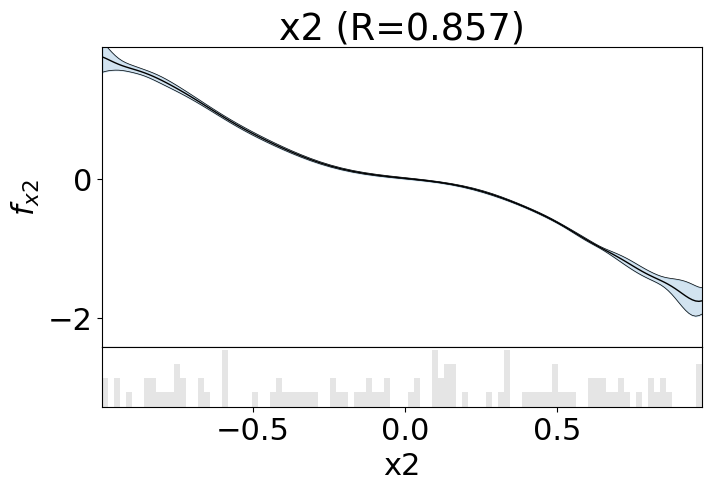

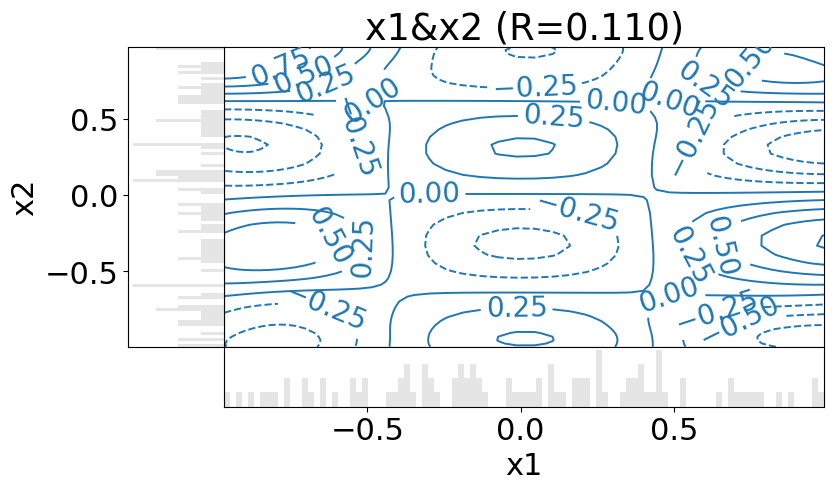

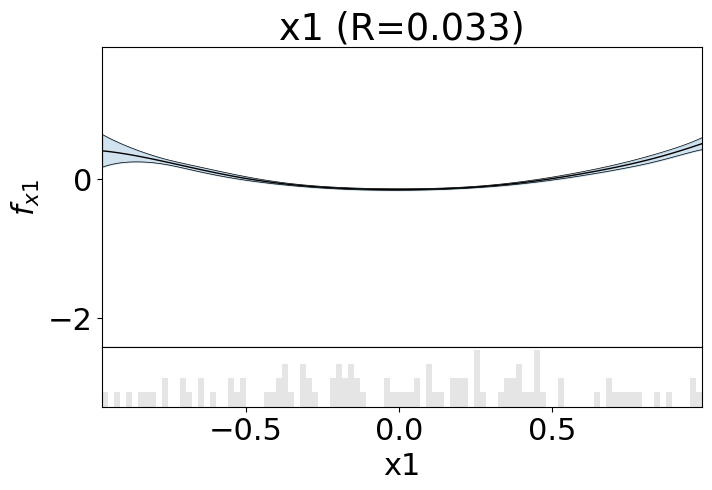

In [197]:
oak_model_instance.plot(top_n=4,
        semilogy=False,
        X_columns=['x1','x2'])

* Plots have feature axes or original values
* What is semilogy?
* Plotting does not work when normalizing flow is False

In [163]:
# TESTING
x1_test = np.random.uniform(x_lower,x_upper,100)
x2_test = np.random.uniform(x_lower,x_upper,100)
f_test = x1**2 - 2*x2 + np.cos(3*x1) * np.sin(5*x2)

X_test = np.column_stack((x1, x2))
F_test = f.reshape(-1,1)

x_max, x_min = X_train.max(0), X_train.min(0)

f_pred = oak_model_instance.predict(np.clip(X_test, x_min, x_max))
rss = ((f_pred - F_test[:, 0]) ** 2).mean()
tss = (
    (F_test[:, 0] - F_test[:, 0].mean() * np.ones(F_test[:, 0].shape)) ** 2
).mean()
r2 = 1 - rss / tss
rmse = np.sqrt(rss)

print(f"oak test rmse = {rmse}, r2 = {r2}\n")

oak test rmse = 0.003292956191495706, r2 = 0.999993616246606



### Test indivdual components

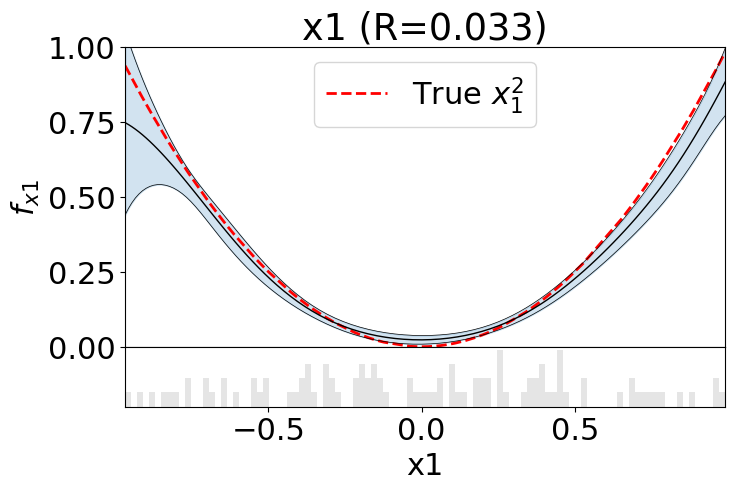

In [196]:
# 2. Prepare Arguments
model_gpflow = oak_model_instance.m # Get the underlying GPR/SGPR model
feature_index = 0 # Index for x1
feature_name = "x1"

# Create the inverse transform function for x
# (Handles the specific scaling used for this feature)
x_inverse_transform = oak_model_instance._get_x_inverse_transformer(feature_index)

# Create the inverse transform function for y
# Needs to handle shape correctly for scaler (expects 2D)
# This lambda assumes the function inside plot_single_effect passes 1D arrays
# for mu, lower, upper and potentially 2D for Y, Y_corrected.
# We focus on transforming the prediction lines correctly.
def y_inverse_transform_wrapper(y_arr):
    # Ensure input is at least 1D before attempting reshape
    if isinstance(y_arr, (np.ndarray, tf.Tensor)):
        y_arr = np.asarray(y_arr) # Convert potential tensor to numpy
        if y_arr.ndim == 0: # Handle scalar case if it occurs
            y_arr_2d = y_arr.reshape(1, 1)
        elif y_arr.ndim == 1: # Expected case for mu, lower, upper
             y_arr_2d = y_arr[:, None]
        else: # Assume already 2D for Y, Y_corrected
            y_arr_2d = y_arr
        return oak_model_instance.scaler_y.inverse_transform(y_arr_2d)[:, 0]
    else:
        # Handle non-array input if necessary, or raise error
        return y_arr # Or raise TypeError

# Optional: Calculate Sobol index if needed for the title
# You might need to run oak_model_instance.get_sobol() first if R is desired
sobol_indices = oak_model_instance.get_sobol()
# Find the index corresponding to the main effect of feature 0
target_dims = (feature_index,)
try:
    sobol_index_for_plot = [idx for idx, dims in enumerate(oak_model_instance.tuple_of_indices) if tuple(dims) == target_dims][0]
    r_value = sobol_indices[sobol_index_for_plot]
    plot_title = f"{feature_name} (R={r_value:.3f})"
except (IndexError, AttributeError):
    print("Warning: Could not retrieve Sobol index for title.")
    plot_title = f"Learned Effect of {feature_name}"


# 3. Call the function
fig_desc = plot_single_effect(
    m=model_gpflow,
    i=feature_index,
    covariate_name=feature_name,
    title=plot_title,
    x_transform=x_inverse_transform,
    y_transform=y_inverse_transform_wrapper, # Use the wrapper
    semilogy=False, # Adjust as needed
    plot_corrected_data=False, # Adjust as needed
    plot_raw_data=False, # Adjust as needed
    quantile_range=[0, 100] # Plot full range by default, adjust if needed
    # Add other optional arguments like ylim, X_list, fontsize etc. if desired
)

fig = fig_desc.fig
ax1 = fig.axes[0]

ax1.plot(np.sort(x1),np.sort(x1)**2,'r--', linewidth=2, label='True $x_1^2$')
ax1.set_ylim(0,1)
ax1.legend()

--- Plotting component for Feature Index: 0 ---
--- Plotting component for Feature Index: 1 ---


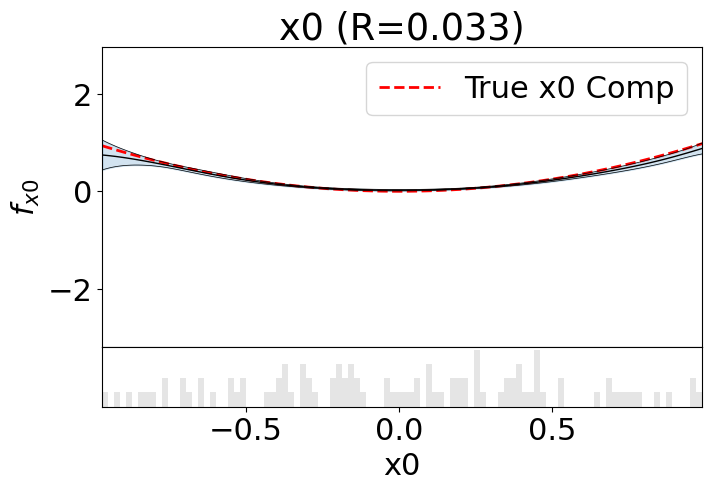

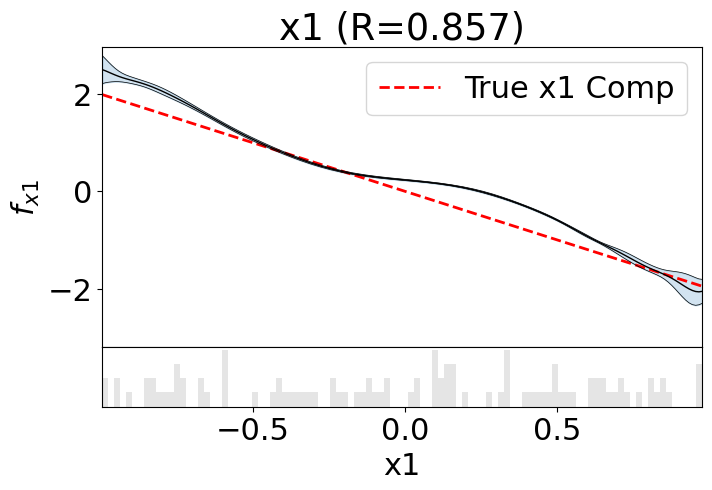

In [191]:

# --- Get model details ---
model_gpflow = oak_model_instance.m
num_dims = oak_model_instance.num_dims # Get number of features
feature_names = [f"x{i}" for i in range(num_dims)] # Example default names

# --- Define y_inverse_transform_wrapper (only need to define once) ---
def y_inverse_transform_wrapper(y_arr):
    if isinstance(y_arr, (np.ndarray, tf.Tensor)):
        y_arr = np.asarray(y_arr)
        if y_arr.ndim == 0:
            y_arr_2d = y_arr.reshape(1, 1)
        elif y_arr.ndim == 1:
             y_arr_2d = y_arr[:, None]
        else:
            y_arr_2d = y_arr
        return oak_model_instance.scaler_y.inverse_transform(y_arr_2d)[:, 0]
    else:
        return y_arr
# --- End y_inverse_transform_wrapper definition ---

# --- Pre-calculate Sobol indices if needed (only need to do once) ---
# Make sure the model has tuple_of_indices attribute if using this
try:
    sobol_indices = oak_model_instance.get_sobol()
    sobol_available = True
except AttributeError:
    print("Warning: Cannot get Sobol indices, 'R' value will not be included in title.")
    sobol_available = False
# --- End Sobol pre-calculation ---

# --- Loop through each feature index for first-order effects ---
for feature_index in range(num_dims):

    print(f"--- Plotting component for Feature Index: {feature_index} ---")

    feature_name = feature_names[feature_index]

    # 2. Prepare Arguments for this feature
    x_inverse_transform = oak_model_instance._get_x_inverse_transformer(feature_index)

    # --- Calculate Title ---
    plot_title = f"Learned Effect of {feature_name}" # Default title
    if sobol_available:
        target_dims = (feature_index,)
        try:
            # Find the Sobol index corresponding to this single dimension tuple
            sobol_index_for_plot = [idx for idx, dims in enumerate(oak_model_instance.tuple_of_indices) if tuple(dims) == target_dims][0]
            r_value = sobol_indices[sobol_index_for_plot]
            plot_title = f"{feature_name} (R={r_value:.3f})"
        except (IndexError, AttributeError, TypeError):
             # Handle cases where tuple_of_indices might not exist or index not found
            print(f"Warning: Could not retrieve Sobol index for feature {feature_index}.")
    # --- End Title calculation ---

    # Define quantile range (can be the same for all or customized)
    plot_quantile_range = [0, 100]

    # 3. Call plot_single_effect for the current feature
    try:
        fig_desc = plot_single_effect(
            m=model_gpflow,
            i=feature_index,
            covariate_name=feature_name,
            title=plot_title,
            x_transform=x_inverse_transform,
            y_transform=y_inverse_transform_wrapper, # Use the wrapper
            semilogy=False,
            plot_corrected_data=False,
            plot_raw_data=False,
            quantile_range=plot_quantile_range
        )
    except Exception as e:
        print(f"ERROR plotting effect for feature {feature_index}: {e}")
        continue # Skip to the next feature if plotting fails

    # 4. Add the true function plot to the existing axes
    fig = fig_desc.fig
    if not fig.axes:
        print(f"Warning: Figure for feature {feature_index} has no axes. Skipping true function plot.")
        continue

    ax1 = fig.axes[0] # Assuming the main plot is the first axes

    # --- Regenerate the x-axis values used in the plot ---
    try:
        X_train_scaled = oak_model_instance.X_scaled
        Xi_scaled = X_train_scaled[:, feature_index]
        xmin_scaled, xmax_scaled = np.percentile(Xi_scaled, (plot_quantile_range[0], plot_quantile_range[1]))
        xx_scaled = np.linspace(xmin_scaled, xmax_scaled, 100)

        if x_inverse_transform:
            x_plot_range_original = x_inverse_transform(xx_scaled)
            if not isinstance(x_plot_range_original, np.ndarray):
                 x_plot_range_original = x_plot_range_original.numpy()
        else:
            # If no inverse transform (e.g., categorical/binary handled differently),
            # this logic might need adjustment or skipping the true plot.
            # For now, assume continuous if x_inverse_transform exists.
             x_plot_range_original = xx_scaled
    except Exception as e:
        print(f"Warning: Could not regenerate x-axis for feature {feature_index}. Skipping true function plot. Error: {e}")
        continue
    # --- End x-axis regeneration ---

    # --- Get and plot the true component function ---
    true_component_key = f'comp{feature_index}' # Assumes keys 'comp0', 'comp1', etc.
    if true_component_key in true_funcs:
        true_component_func = true_funcs[true_component_key]
        try:
            # Calculate true y-values
            yy_true = true_component_func(x_plot_range_original)

            # Plot the true function on ax1
            ax1.plot(x_plot_range_original, yy_true, 'r--', linewidth=2, label=f'True {feature_name} Comp')

            # Update the legend
            ax1.legend()

            # Optional: Adjust y-limits
            current_ylim = ax1.get_ylim()
            min_y = min(current_ylim[0], np.min(yy_true))
            max_y = max(current_ylim[1], np.max(yy_true))
            ax1.set_ylim(min_y - (max_y-min_y)*0.05, max_y + (max_y-min_y)*0.05) # Add padding

        except Exception as e:
            print(f"Warning: Could not calculate or plot true function for feature {feature_index}. Error: {e}")
    else:
        print(f"Warning: No true component function found for index {feature_index} (key: {true_component_key})")
    # --- End true component plotting ---

    # 5. Display the plot for the current feature
    # fig.show() # Use this if you want interactive windows
    # Alternatively, collect figures in a list and display all at the end

# --- Show all plots at the end if not shown in the loop ---
plt.show() # This will display all figures created in the loop